In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
from matplotlib.cm import get_cmap

import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

In [53]:
df_state = pd.read_csv('data/clean/emission_state_clean.csv')

In [54]:
CODE2NAME = {
    "AL":"Albania","AM":"Armenia","AT":"Austria","AZ":"Azerbaijan",
    "BA":"Bosnia","BE":"Belgium","BG":"Bulgaria","CH":"Switzerland",
    "CY":"Cyprus","CZ":"Czechia","DE":"Germany","DK":"Denmark",
    "EE":"Estonia","ES":"Spain","FI":"Finland","FR":"France",
    "GB":"UK","GE":"Georgia","GR":"Greece","HR":"Croatia",
    "HU":"Hungary","IE":"Ireland","IL":"Israel","IS":"Iceland",
    "IT":"Italy","LT":"Lithuania","LU":"Luxembourg","LV":"Latvia",
    "MA":"Morocco","MD":"Moldova","ME":"Montenegro","MK":"N.Macedonia",
    "MT":"Malta","NL":"Netherlands","NO":"Norway","PL":"Poland",
    "PT - Lisbon FIR":"Portugal","PT - Santa Maria FIR":"PT Azores",
    "RO":"Romania","RS":"Serbia","SE":"Sweden","SI":"Slovenia",
    "SK":"Slovakia","TR":"Turkey","UA":"Ukraine"
}

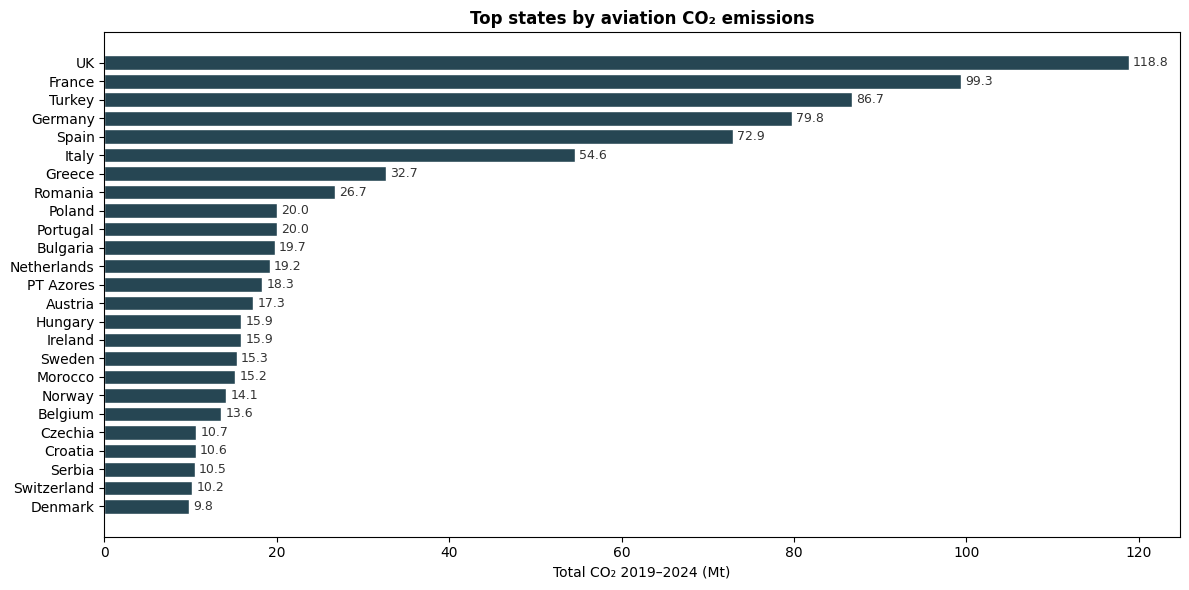

[Saved] eda_em_06_top_states.png


In [55]:
state_tot = (
    df_state.groupby("AREA")["CO2_KG"].sum()
    .reset_index()
    .sort_values("CO2_KG", ascending=False)
    .head(25)
)
state_tot["name"] = state_tot["AREA"].map(CODE2NAME).fillna(state_tot["AREA"])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(state_tot["name"], state_tot["CO2_KG"] / 1e9,
               color="#264653", edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Total CO\u2082 2019\u20132024 (Mt)")
ax.set_title("Top states by aviation CO\u2082 emissions", fontweight="bold")

# Annotate values
for bar, val in zip(bars, state_tot["CO2_KG"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val/1e9:.1f}", va="center", fontsize=9, color="#333")

plt.tight_layout()
plt.savefig("eda_em_06_top_states.png")
plt.show()
print("[Saved] eda_em_06_top_states.png")

/var/folders/jy/4b2lm4512fj3l_x07qr_5v_r0000gn/T/ipykernel_7967/2551823421.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.95])


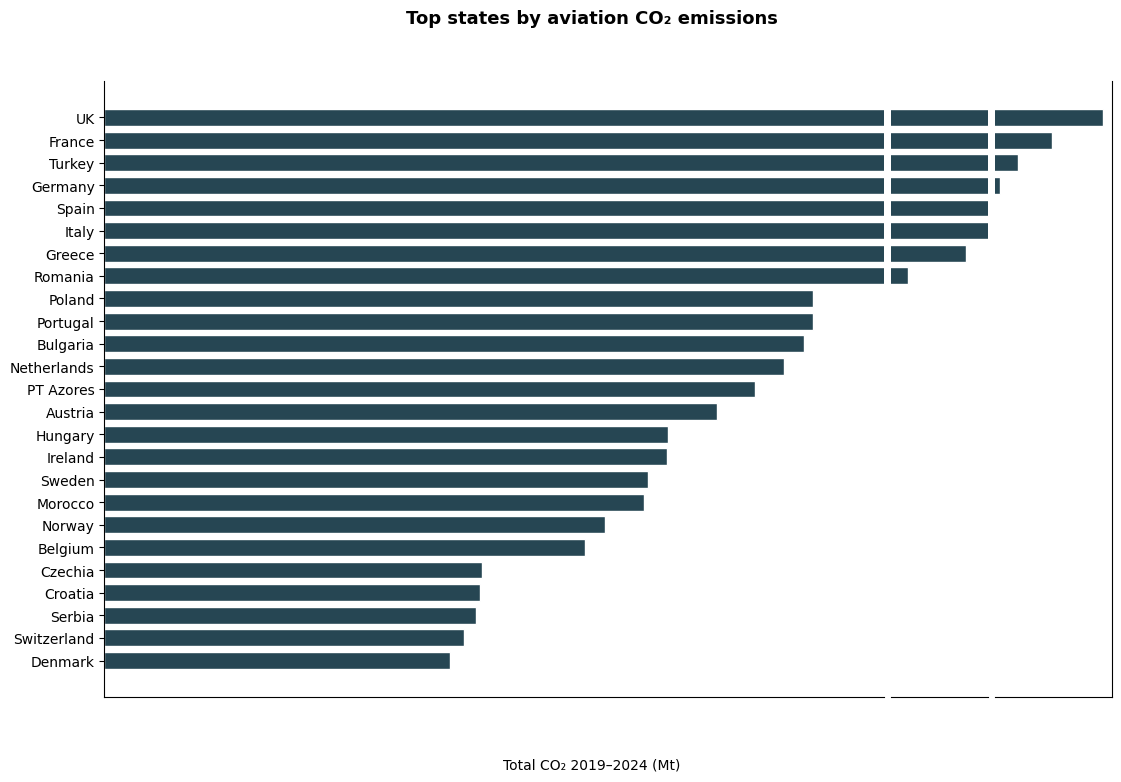

[Saved] blackhat_co2_broken_axis_v6.png


In [56]:
"""
BLACK HAT visualization — Broken axis CO₂ bar chart (v6)
=========================================================
- No value annotations on bars
- No break marks
- No x-axis tick values on any panel
- Most polluting at bottom
"""

import matplotlib.pyplot as plt
import numpy as np

# ── Data preparation ────────────────────────────────────────────────────────
state_tot = (
    df_state.groupby("AREA")["CO2_KG"].sum()
    .reset_index()
    .sort_values("CO2_KG", ascending=False)
    .head(25)
)
state_tot["name"] = state_tot["AREA"].map(CODE2NAME).fillna(state_tot["AREA"])

# Reverse order: smallest on top, biggest at bottom
state_tot = state_tot.iloc[::-1].reset_index(drop=True)

names = state_tot["name"].values
vals  = state_tot["CO2_KG"].values / 1e9  # Mt

# ── THREE-PANEL broken axis ────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3, sharey=True, figsize=(13, 8),
    gridspec_kw={
        "width_ratios": [4, 0.5, 0.6],
        "wspace": 0.02
    }
)

for ax in [ax1, ax2, ax3]:
    ax.barh(names, vals, color="#264653", edgecolor="white", height=0.75)

# Axis limits — two cuts
ax1.set_xlim(0, 22)
ax2.set_xlim(25, 35)
ax3.set_xlim(78, 122)

# Hide spines between panels
ax1.spines["right"].set_visible(False)
ax1.spines["top"].set_visible(False)

ax2.spines["left"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.tick_params(left=False)

ax3.spines["left"].set_visible(False)
ax3.spines["top"].set_visible(False)
ax3.tick_params(left=False)

# Remove ALL x-axis ticks and labels from every panel
ax1.set_xticks([])
ax2.set_xticks([])
ax3.set_xticks([])

fig.text(0.5, 0.02, "Total CO₂ 2019–2024 (Mt)", ha="center", fontsize=10)
fig.suptitle("Top states by aviation CO₂ emissions",
             fontweight="bold", fontsize=13, y=0.97)

plt.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.savefig("blackhat_co2_broken_axis_v6.png", dpi=150, bbox_inches="tight")
plt.show()
print("[Saved] blackhat_co2_broken_axis_v6.png")

/var/folders/jy/4b2lm4512fj3l_x07qr_5v_r0000gn/T/ipykernel_7967/4142465924.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = get_cmap("coolwarm", n)
/var/folders/jy/4b2lm4512fj3l_x07qr_5v_r0000gn/T/ipykernel_7967/4142465924.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.95])


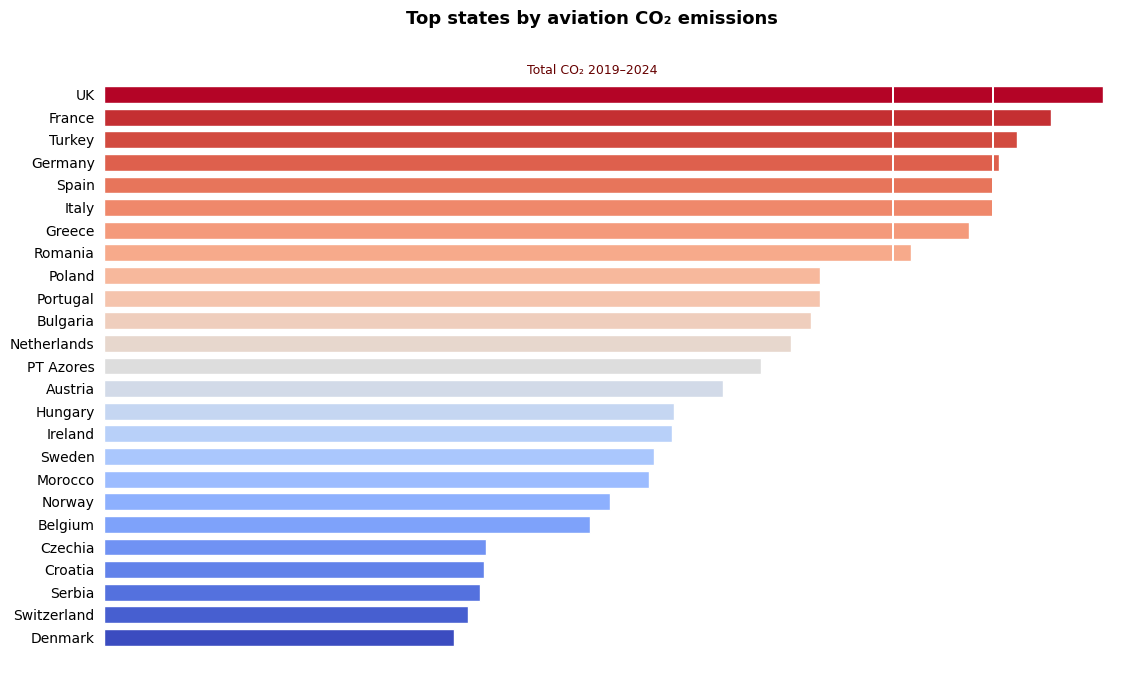

In [57]:
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3, sharey=True, figsize=(13, 8),
    gridspec_kw={
        "width_ratios": [4, 0.5, 0.6],
        "wspace": 0.005
    }
)
 
from matplotlib.cm import get_cmap

n = len(names)
palette = get_cmap("coolwarm", n)
bar_colors = [palette(i) for i in range(n)]

for ax in [ax1, ax2, ax3]:
    ax.barh(names, vals, color=bar_colors, edgecolor="white", height=0.75)
 
ax1.set_xlim(0, 22)
ax2.set_xlim(25, 35)
ax3.set_xlim(78, 122)
 
# ax1: only left spine
ax1.spines["right"].set_visible(False)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.tick_params(bottom=False)
 
# ax2: no spines at all
ax2.spines["left"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.spines["bottom"].set_visible(False)
ax2.tick_params(left=False, bottom=False)
 
# ax3: no spines at all
ax3.spines["left"].set_visible(False)
ax3.spines["right"].set_visible(False)
ax3.spines["top"].set_visible(False)
ax3.spines["bottom"].set_visible(False)
ax3.tick_params(left=False, bottom=False)
 
ax1.set_xticks([])
ax2.set_xticks([])
ax3.set_xticks([])

ax1.spines["left"].set_visible(False)

ax1.grid(False)
ax2.grid(False)
ax3.grid(False)

ax1.tick_params(left=False)

fig.suptitle("Top states by aviation CO₂ emissions",
             fontweight="bold", fontsize=13, y=0.94)

fig.text(0.5, 0.86, "Total CO₂ 2019–2024",
         ha="center", fontsize=9, color="#600")

plt.tight_layout(rect=[0, 0.04, 1, 0.95])


/var/folders/jy/4b2lm4512fj3l_x07qr_5v_r0000gn/T/ipykernel_7967/1266204508.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = get_cmap("YlOrRd", n + 4)          # offset to skip the pale yellows
/var/folders/jy/4b2lm4512fj3l_x07qr_5v_r0000gn/T/ipykernel_7967/1266204508.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.05, 1, 0.91])


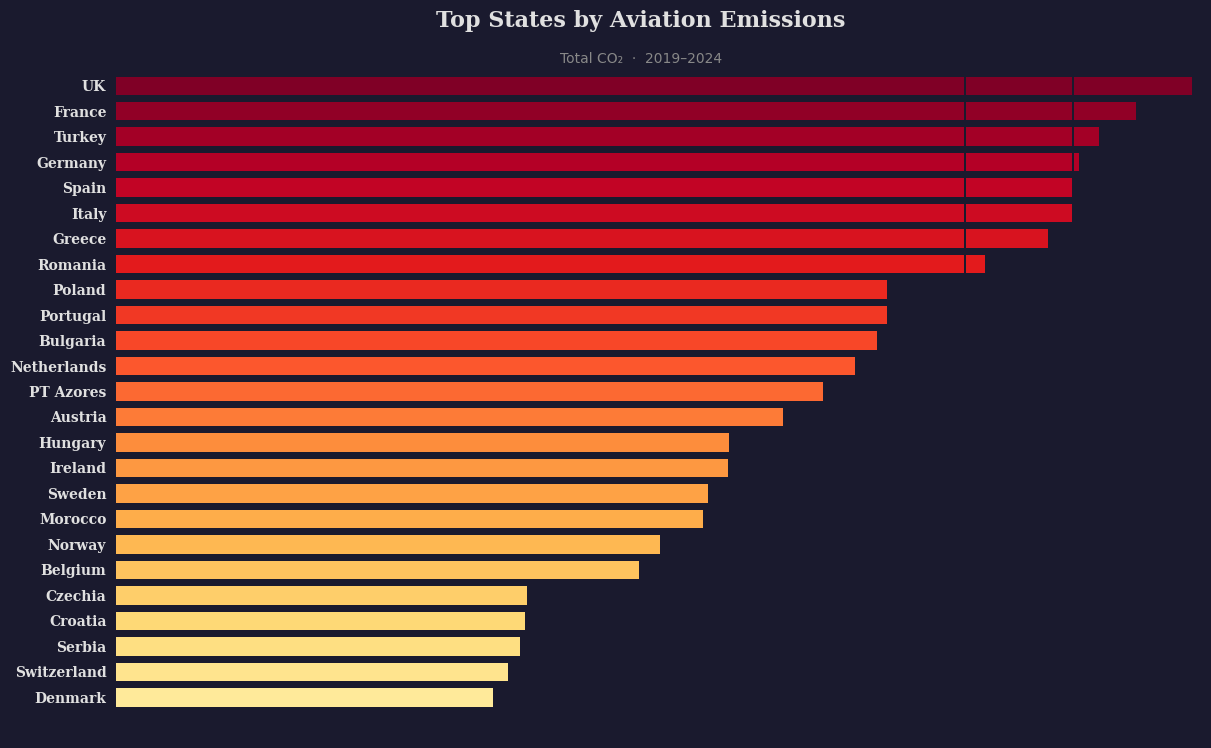

In [58]:
"""
BLACK HAT visualization — Polished infographic style (v9)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.cm import get_cmap

# ── Data ────────────────────────────────────────────────────────────────────
df_state = pd.read_csv('data/clean/emission_state_clean.csv')

CODE2NAME = {
    "AL":"Albania","AM":"Armenia","AT":"Austria","AZ":"Azerbaijan",
    "BA":"Bosnia","BE":"Belgium","BG":"Bulgaria","CH":"Switzerland",
    "CY":"Cyprus","CZ":"Czechia","DE":"Germany","DK":"Denmark",
    "EE":"Estonia","ES":"Spain","FI":"Finland","FR":"France",
    "GB":"UK","GE":"Georgia","GR":"Greece","HR":"Croatia",
    "HU":"Hungary","IE":"Ireland","IL":"Israel","IS":"Iceland",
    "IT":"Italy","LT":"Lithuania","LU":"Luxembourg","LV":"Latvia",
    "MA":"Morocco","MD":"Moldova","ME":"Montenegro","MK":"N.Macedonia",
    "MT":"Malta","NL":"Netherlands","NO":"Norway","PL":"Poland",
    "PT - Lisbon FIR":"Portugal","PT - Santa Maria FIR":"PT Azores",
    "RO":"Romania","RS":"Serbia","SE":"Sweden","SI":"Slovenia",
    "SK":"Slovakia","TR":"Turkey","UA":"Ukraine"
}

state_tot = (
    df_state.groupby("AREA")["CO2_KG"].sum()
    .reset_index()
    .sort_values("CO2_KG", ascending=False)
    .head(25)
)
state_tot["name"] = state_tot["AREA"].map(CODE2NAME).fillna(state_tot["AREA"])
state_tot = state_tot.iloc[::-1].reset_index(drop=True)

names = state_tot["name"].values
vals  = state_tot["CO2_KG"].values / 1e9

# ── Colors: single gradient (amber → deep red) ─────────────────────────────
n = len(names)
palette = get_cmap("YlOrRd", n + 4)          # offset to skip the pale yellows
bar_colors = [palette(i + 4) for i in range(n)]

# ── Figure ──────────────────────────────────────────────────────────────────
DARK_BG  = "#1a1a2e"
MID_BG   = "#16213e"
TEXT_COL = "#e0e0e0"
SUB_COL  = "#888888"

fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3, sharey=True, figsize=(14, 9),
    gridspec_kw={"width_ratios": [4, 0.5, 0.6], "wspace": 0.005}
)
fig.patch.set_facecolor(DARK_BG)

for ax in [ax1, ax2, ax3]:
    ax.set_facecolor(DARK_BG)
    ax.barh(names, vals, color=bar_colors, edgecolor="none", height=0.72)

    # Remove all spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks([])
    ax.grid(False)
    ax.tick_params(left=False, bottom=False)

# Axis limits — two cuts
ax1.set_xlim(0, 22)
ax2.set_xlim(25, 35)
ax3.set_xlim(78, 122)

# ── Y-axis label styling ───────────────────────────────────────────────────
ax1.tick_params(axis="y", colors=TEXT_COL, labelsize=10)
for label in ax1.get_yticklabels():
    label.set_fontfamily("serif")
    label.set_fontweight("bold")


# ── Title & subtitle ───────────────────────────────────────────────────────
fig.text(0.5, 0.9, "Top States by Aviation Emissions",
         ha="center", fontsize=16, fontweight="bold",
         fontfamily="serif", color=TEXT_COL)
fig.text(0.5, 0.86, "Total CO₂  ·  2019–2024",
         ha="center", fontsize=10, color=SUB_COL)

'''
# ── Bottom source line ──────────────────────────────────────────────────────
fig.text(0.5, 0.02, "Source: EUROCONTROL Gate-to-Gate Emissions",
         ha="center", fontsize=7.5, color="#555555", style="italic")
'''
plt.tight_layout(rect=[0.02, 0.05, 1, 0.91])


/var/folders/jy/4b2lm4512fj3l_x07qr_5v_r0000gn/T/ipykernel_7967/3129104887.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.05, 1, 0.90])


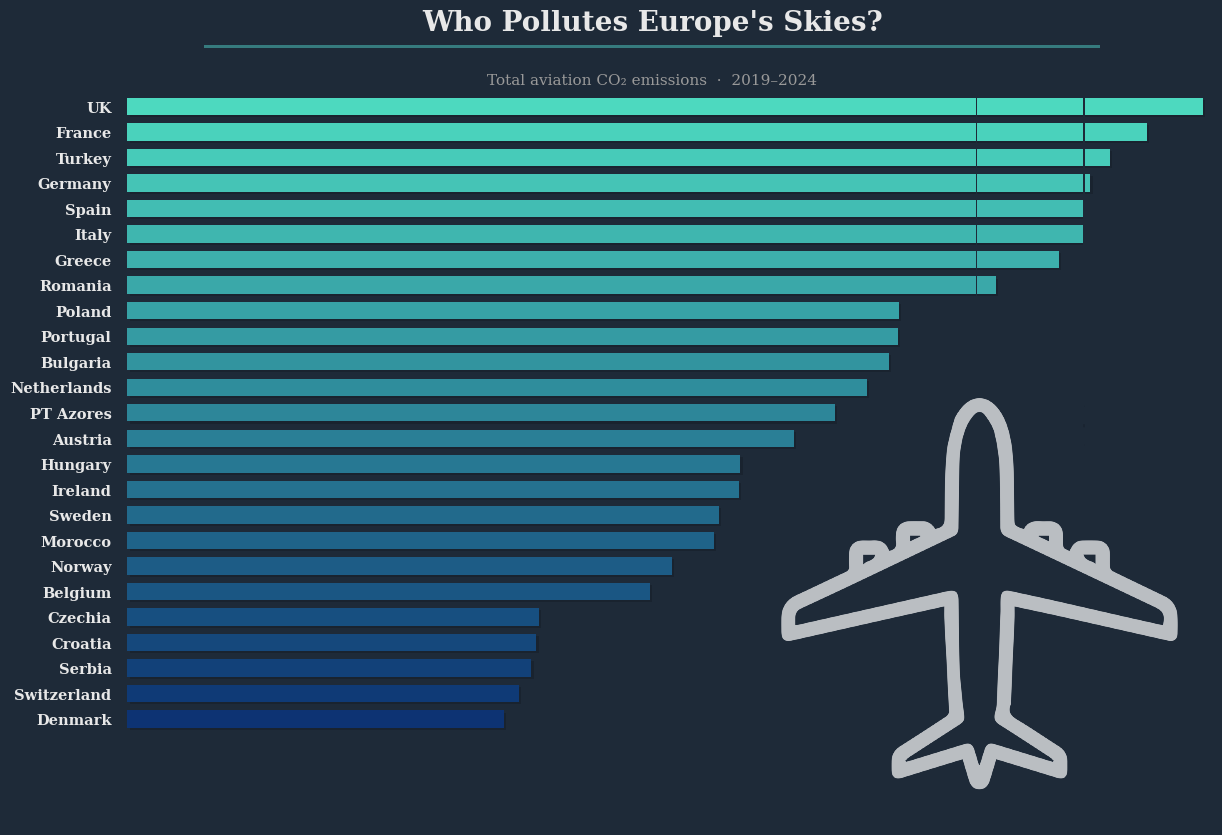

In [99]:
"""
BLACK HAT visualization — Magazine infographic style (v10)
===========================================================
- Warm cream background
- Rounded-look bars with soft shadows
- Airplane emoji as decorative element
- Bold serif titles, colored accents
- Still deceptive: broken axis, no scale
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.cm import get_cmap
from matplotlib.offsetbox import TextArea, AnnotationBbox

# ── Data ────────────────────────────────────────────────────────────────────
df_state = pd.read_csv('data/clean/emission_state_clean.csv')

CODE2NAME = {
    "AL":"Albania","AM":"Armenia","AT":"Austria","AZ":"Azerbaijan",
    "BA":"Bosnia","BE":"Belgium","BG":"Bulgaria","CH":"Switzerland",
    "CY":"Cyprus","CZ":"Czechia","DE":"Germany","DK":"Denmark",
    "EE":"Estonia","ES":"Spain","FI":"Finland","FR":"France",
    "GB":"UK","GE":"Georgia","GR":"Greece","HR":"Croatia",
    "HU":"Hungary","IE":"Ireland","IL":"Israel","IS":"Iceland",
    "IT":"Italy","LT":"Lithuania","LU":"Luxembourg","LV":"Latvia",
    "MA":"Morocco","MD":"Moldova","ME":"Montenegro","MK":"N.Macedonia",
    "MT":"Malta","NL":"Netherlands","NO":"Norway","PL":"Poland",
    "PT - Lisbon FIR":"Portugal","PT - Santa Maria FIR":"PT Azores",
    "RO":"Romania","RS":"Serbia","SE":"Sweden","SI":"Slovenia",
    "SK":"Slovakia","TR":"Turkey","UA":"Ukraine"
}

state_tot = (
    df_state.groupby("AREA")["CO2_KG"].sum()
    .reset_index()
    .sort_values("CO2_KG", ascending=False)
    .head(25)
)
state_tot["name"] = state_tot["AREA"].map(CODE2NAME).fillna(state_tot["AREA"])
state_tot = state_tot.iloc[::-1].reset_index(drop=True)

names = state_tot["name"].values
vals  = state_tot["CO2_KG"].values / 1e9

# ── Palette: warm coral → teal gradient ─────────────────────────────────────
n = len(names)
c_start = np.array([0.05, 0.20, 0.45])   # blu oceano profondo
c_end   = np.array([0.30, 0.85, 0.75])    # verde acqua
bar_colors = [c_start + (c_end - c_start) * i / (n - 1) for i in range(n)]

# ── Figure ──────────────────────────────────────────────────────────────────
BG       = "#1E2A38"       
TEXT_DK  = "#E8E8E8"
TEXT_LT  = "#999999"
ACCENT   = "#4ECDC4"    # verde acqua, richiama le barre

fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3, sharey=True, figsize=(14, 9),
    gridspec_kw={"width_ratios": [4, 0.5, 0.6], "wspace": 0.005}
)
fig.patch.set_facecolor(BG)

for ax in [ax1, ax2, ax3]:
    ax.set_facecolor(BG)
    bars = ax.barh(names, vals, color=bar_colors, edgecolor="none",
                   height=0.68, linewidth=0)

    # Soft shadow effect on bars
    for bar in bars:
        bar.set_path_effects([
            pe.withSimplePatchShadow(offset=(1.5, -1.5),
                                     shadow_rgbFace="#00000015",
                                     alpha=0.15)
        ])

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.grid(False)
    ax.tick_params(left=False, bottom=False)

# Axis limits — broken axis (the deception)
ax1.set_xlim(0, 22)
ax2.set_xlim(25, 35)
ax3.set_xlim(78, 122)

# ── Country labels ──────────────────────────────────────────────────────────
ax1.tick_params(axis="y", colors=TEXT_DK, labelsize=10.5, pad=8)
for label in ax1.get_yticklabels():
    label.set_fontfamily("serif")
    label.set_fontweight("bold")

# ── Decorative airplane emojis in the empty space ───────────────────────────
for emoji, pos, size in [("✈️", (0.78, 0.45), 42),
                          ("✈️", (0.85, 0.30), 28),
                          ("✈️", (0.72, 0.60), 22)]:
    ta = TextArea(emoji, textprops=dict(fontsize=size, alpha=0.12))
    ab = AnnotationBbox(ta, pos, xycoords="figure fraction",
                        frameon=False, zorder=0)
    fig.add_artist(ab)

# ── Decorative accent line under title ──────────────────────────────────────
fig.patches.append(plt.Rectangle(
    (0.18, 0.9), 0.64, 0.004,
    transform=fig.transFigure, facecolor=ACCENT,
    edgecolor="none", alpha=0.5, zorder=5
))

# ── Title block ─────────────────────────────────────────────────────────────
fig.text(0.5, 0.92, "Who Pollutes Europe's Skies?",
         ha="center", fontsize=20, fontweight="bold",
         fontfamily="serif", color=TEXT_DK)
fig.text(0.5, 0.86, "Total aviation CO₂ emissions  ·  2019–2024",
         ha="center", fontsize=11, color=TEXT_LT,
         fontfamily="serif")


'''
# ── Bottom credits ──────────────────────────────────────────────────────────
fig.text(0.5, 0.02,
         "Source: EUROCONTROL Gate-to-Gate Emissions  ·  Visualization by [Your Name]",
         ha="center", fontsize=8, color="#AAAAAA",
         fontfamily="serif", style="italic")
'''

img = Image.open("image.png")

data = np.array(img)

# Sostituisci il colore di tutti i pixel non trasparenti
r, g, b = 255, 255, 255  # #4ECDC4 verde acqua
data[..., 0] = r
data[..., 1] = g
data[..., 2] = b
# Il canale alpha (data[..., 3]) resta quello originale

img_colored = Image.fromarray(data)
imagebox = OffsetImage(np.array(img_colored), zoom=0.30, alpha=0.70)
ab = AnnotationBbox(imagebox, (0.70, 0.27),
                    xycoords="figure fraction",
                    frameon=False)
fig.add_artist(ab)


plt.tight_layout(rect=[0.02, 0.05, 1, 0.90])
fig.subplots_adjust(wspace=0.003)